# λ vs. T<sub>eff</sub> for Hot Jupiters

This notebook reproduces the classic sky-projected stellar obliquity vs. host effective temperature" diagram for the hot-Jupiter population, using the live SOCat catalog.

**Hot Jupiter definition used here**

- $a/R_\star < 10$  (close-in)
- $M_p > 0.3\,M_{\rm Jup}$  (giant)

**Measurement selection (one row per planet)**

- Methods kept: `RM`, `DT`, `RRM`, `RMR` (direct obliquity techniques only).
- Priority per planet: our own RM measurement (`pl_projobliq_ref == "WWB"`) wins; otherwise we use the row marked by SOCat as primary (`SOCatflag == "y"`).

In [58]:
import io, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
from matplotlib.ticker import MultipleLocator, \
    FormatStrFormatter, AutoMinorLocator
def ticksetax(ax, labelsize=15, ticksize=12, tickwidth=1.5, ticklength=5):
    ax.tick_params(direction='in', which='both',  width=2,colors='k', bottom='True',top='True', left='True', right='True', labelsize=15)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['right'].set_linewidth(2)
    ax.spines['top'].set_linewidth(2)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

# Use STIX (Times-like) font for all plots — matplotlib-bundled, no download needed
plt.rcParams['font.family']      = 'STIXGeneral'
plt.rcParams['mathtext.fontset'] = 'stix'

# Fetch the catalog directly from the SOCat website on every run.
#   • In JupyterLite/Pyodide  → use the browser fetch bridge (pyodide.http.pyfetch)
#   • In regular CPython      → shell out to wget, which Cloudflare's
#                                bot-detection doesn't block (urllib's default
#                                'Python-urllib/...' UA is 403'd).
SOCAT_CSV_URL  = 'https://www.stellarobliquity.com/app/static/obliquitywwb.csv'
LOCAL_CSV_NAME = 'obliquitywwb.csv'
try:
    from pyodide.http import pyfetch          # JupyterLite / Pyodide
    resp     = await pyfetch(SOCAT_CSV_URL)
    csv_text = await resp.string()
    df       = pd.read_csv(io.StringIO(csv_text), comment='#')
except ImportError:                            # regular CPython
    os.system(f"wget -q {SOCAT_CSV_URL} -O {LOCAL_CSV_NAME}")
    df = pd.read_csv(LOCAL_CSV_NAME, comment='#')

print(f'Loaded {len(df)} obliquity measurements across {df["hostname"].nunique()} host stars')
df.head()

Loaded 713 obliquity measurements across 298 host stars


,pl_defaultname,Pflag,SOCatflag,pl_projobliq,pl_projobliqerr1,pl_projobliqerr2,pl_trueobliq,pl_trueobliqerr1,pl_trueobliqerr2,Method,...,st_age,st_ageerr1,st_ageerr2,st_vsin,st_vsinerr1,st_vsinerr2,rv_flag,tran_flag,peak_prob,System
0,55 Cnc e,n,n,72.4,12.7,-11.5,NaN,NaN,NaN,RM,...,7.800,3.800,-4.000,1.5,1.2,-0.7,1.0,1.0,1.0,55 Cnc e
1,55 Cnc e,y,y,10.0,17.0,-20.0,23.0,14.0,-12.0,RM,...,7.800,3.800,-4.000,1.5,1.2,-0.7,1.0,1.0,1.0,55 Cnc e
2,AU Mic b,y,n,-4.7,6.8,-6.4,NaN,NaN,NaN,DT,...,0.022,0.003,-0.003,8.5,0.2,-0.2,1.0,1.0,NaN,AU Mic b
3,AU Mic b,n,n,-0.1,5.1,-5.0,NaN,NaN,NaN,RM,...,0.022,0.003,-0.003,8.5,0.2,-0.2,1.0,1.0,NaN,AU Mic b
4,AU Mic b,n,n,-3.0,10.4,-10.3,NaN,NaN,NaN,RM,...,0.022,0.003,-0.003,8.5,0.2,-0.2,1.0,1.0,NaN,AU Mic b


In [59]:
# 1. Hot-Jupiter selection: close-in (a/R* < 10) AND giant (Mp > 0.3 MJup).
#    NEA-style schema:  pl_ratdor = a/R*,  pl_massj = Mp in Jupiter masses.
hj = df[(df['pl_ratdor'] < 10) & (df['pl_massj'] > 0.3)].copy()

# 2. Keep only direct λ-measurement techniques.
ALLOWED_METHODS = ['RM', 'DT', 'RRM', 'RMR']
hj = hj[hj['Method'].isin(ALLOWED_METHODS)]

# 3. One row per planet, by priority:
#       0 → our own RM       (pl_projobliq_ref == 'WWB')
#       1 → SOCat-selected   (SOCatflag == 'y')
#       2 → anything else (fallback; rare)
priority = np.where(
    hj['pl_projobliq_ref'].eq('WWB'), 0,
    np.where(hj['SOCatflag'].astype(str).str.lower().eq('y'), 1, 2),
)
hj_one = (hj.assign(_priority=priority)
            .sort_values(['pl_defaultname', '_priority'])
            .drop_duplicates(subset='pl_defaultname', keep='first')
            .drop(columns='_priority')
            .reset_index(drop=True))

n_wwb = (hj_one['pl_projobliq_ref'] == 'WWB').sum()
n_lit = len(hj_one) - n_wwb
pl_defaultname = hj_one['pl_defaultname'].tolist()
print(f'Hot Jupiters (one row per planet): {len(hj_one)}')
print(f'  from WWB (our own RM)          : {n_wwb}')
print(f'  from SOCatflag="y" (literature): {n_lit}')
hj_one[['pl_defaultname', 'pl_massj', 'pl_ratdor', 'st_teff',
        'pl_projobliq', 'Method', 'pl_projobliq_ref']].head()

Hot Jupiters (one row per planet): 154
  from WWB (our own RM)          : 127
  from SOCatflag="y" (literature): 27


,pl_defaultname,pl_massj,pl_ratdor,st_teff,pl_projobliq,Method,pl_projobliq_ref
0,CoRoT-1 b,1.130,4.8239,5950,77.0,RM,Pont_et_al._(2010)
1,CoRoT-11 b,2.890,6.9100,6650,0.1,DT,Gandolfi_et_al._(2012)
2,CoRoT-18 b,3.370,7.0900,5633,-21.0,RM,WWB
3,CoRoT-19 b,1.193,6.8600,5900,-25.0,RM,WWB
4,CoRoT-2 b,3.450,6.7100,5610,32.9,RM,WWB


## λ vs T$_{\rm eff}$ — hot Jupiter sample

Each point is one obliquity measurement of a hot Jupiter; horizontal/vertical bars show 1σ uncertainties. λ is normalized to [0°, 180°] below (negative → +360, then folded around 180). The dashed line marks the **Kraft break** at T<sub>eff</sub> ≈ 6250 K, above which hot Jupiters preferentially show misalignments.

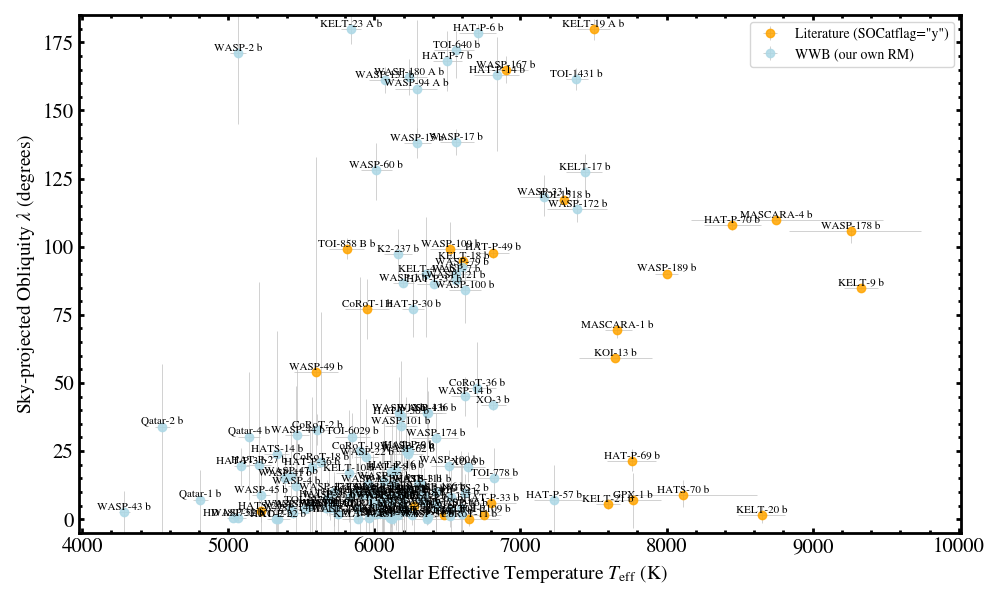

Plotted 154 of 154 hot Jupiters (others missing Teff or λ).


In [60]:
def normalize_lambda(lam, err1, err2):
    """Fold λ into [0, 180]. NEA-style err1=+upper, err2=-lower (negative).
    Returns (value, +upper_err magnitude, +lower_err magnitude)."""
    lam_out, lo_out, hi_out = [], [], []
    for v, e1, e2 in zip(lam, err1, err2):
        if pd.isna(v):
            lam_out.append(np.nan); lo_out.append(np.nan); hi_out.append(np.nan); continue
        x = v + 360 if v < 0 else v
        if 0 <= x < 180:
            lam_out.append(x);          lo_out.append(abs(e2)); hi_out.append(abs(e1))
        else:
            lam_out.append(360 - x);    lo_out.append(abs(e1)); hi_out.append(abs(e2))
    return np.array(lam_out), np.array(lo_out), np.array(hi_out)

good = hj_one.dropna(subset=['st_teff', 'pl_projobliq']).copy()

# Naming follows the catalog schema (NEA-style):
#   pl_projobliq_norm           — λ folded into [0, 180] deg
#   pl_projobliq_norm_err_lo    — positive-magnitude lower error
#   pl_projobliq_norm_err_hi    — positive-magnitude upper error
(good['pl_projobliq_norm'],
 good['pl_projobliq_norm_err_lo'],
 good['pl_projobliq_norm_err_hi']) = normalize_lambda(
    good['pl_projobliq'].values,
    good['pl_projobliqerr1'].values,
    good['pl_projobliqerr2'].values,
)

# Colour the WWB rows so they stand out from literature rows.
is_wwb = good['pl_projobliq_ref'].eq('WWB').values

fig, ax = plt.subplots(figsize=(10, 6))
for mask, color, marker, ms, lbl in [
    (~is_wwb, 'orange', 'o', 6, f'Literature (SOCatflag="y")'),
    ( is_wwb, 'lightblue', 'o', 6, f'WWB (our own RM)'),
]:
    sub = good[mask]
    ax.errorbar(
        sub['st_teff'], sub['pl_projobliq_norm'],
        xerr=[sub['st_tefferr2'].abs(), sub['st_tefferr1'].abs()],
        yerr=[sub['pl_projobliq_norm_err_lo'], sub['pl_projobliq_norm_err_hi']],
        fmt=marker, ms=ms, lw=0.6, alpha=0.85, color=color, label=lbl, ecolor='silver', capsize=3, capthick=0.,
    )
    for _, row in sub.iterrows():
        ax.text(row['st_teff'], row['pl_projobliq_norm'], row['pl_defaultname'], fontsize=8, ha='center', va='bottom')

ax.set_xlabel(r'Stellar Effective Temperature $T_{\rm eff}$ (K)', fontsize=14)
ax.set_ylabel(r'Sky-projected Obliquity $\lambda$ (degrees)',     fontsize=14)
# ax.set_xlim(4000, 7500)
ax.set_ylim(-5, 185)
ax.legend()
ticksetax(ax, labelsize=12, ticksize=10, tickwidth=1.5, ticklength=5)
plt.tight_layout()
plt.show()

print(f'Plotted {len(good)} of {len(hj_one)} hot Jupiters (others missing Teff or λ).')